# F-18 6-DOF Deep Reinforcement Learning — Motion Primitive Path Tracking

**Aircraft Model:** F/A-18 Hornet (6-DOF nonlinear dynamics)  
**Algorithm:** SAC (Soft Actor-Critic) — continuous action space, sample-efficient, stable  
**Maneuver Library:** 70 motion primitives × 7 types (pull-up, push-over, pull-down, high-G turns, slice turns)  
**Objective:** Track reference state trajectories from the maneuver library using DRL control

---
## Architecture Overview
```
ManeuverLibrary (.mat)
      │
      ▼
Reference Trajectories (13 states × 2000 steps × 70 maneuvers)
      │
      ▼
F18_6DOF_Env (Gymnasium)
  ├── F-18 6-DOF Equations of Motion
  ├── Aerodynamic Model (look-up table based)
  ├── Observation: [state_error(13) + current_state(13) + ref_state(13) + time_remaining(1)]
  └── Action: [dThrust, dElevator, dAileron, dRudder] incremental
      │
      ▼
SAC Agent (stable-baselines3)
  ├── Actor: MLP 256-256
  └── Critic: MLP 256-256 (twin Q)
      │
      ▼
Training → Evaluation → Simulation Plots
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


## 1. Imports & Setup

In [3]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
import warnings, os, time
from collections import defaultdict

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.noise import NormalActionNoise
import torch

warnings.filterwarnings('ignore')
np.random.seed(42)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

PyTorch: 2.10.0+cpu
CUDA available: False
Device: cpu


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Load & Parse Maneuver Library

In [4]:
# ── Load .mat file ──────────────────────────────────────────────────────────
MAT_FILE = '/content/drive/MyDrive/maneuver_library (1).mat'   # adjust path if needed
mat = sio.loadmat(MAT_FILE)
lib_raw = mat['maneuver_library']       # shape (1, 70)

# ── State / control labelling (F-18 6-DOF convention) ───────────────────────
STATE_NAMES = [
    'V (m/s)',        # 0  total airspeed
    'α (rad)',        # 1  angle of attack
    'β (rad)',        # 2  sideslip angle
    'φ (rad)',        # 3  roll angle
    'θ (rad)',        # 4  pitch angle
    'ψ (rad)',        # 5  yaw angle
    'p (rad/s)',      # 6  roll rate
    'q (rad/s)',      # 7  pitch rate
    'r (rad/s)',      # 8  yaw rate
    'p_N (m)',        # 9  north position
    'p_E (m)',        # 10 east position
    'p_D (m)',        # 11 down position (unused in this dataset)
    'h (m)',          # 12 altitude (positive up, stored as –h_NED)
]

CTRL_NAMES = ['Thrust (N)', 'Elevator (rad)', 'Aileron (rad)', 'Rudder (rad)']
N_STATES   = 13
N_CTRL     = 4

# ── Parse all 70 entries ─────────────────────────────────────────────────────
class Maneuver:
    """Container for one motion primitive."""
    def __init__(self, idx, raw):
        self.idx           = idx
        self.maneuver_type = str(raw['maneuver_type'][0][0][0])
        self.duration      = float(raw['duration'][0][0].flat[0])
        self.Nz            = float(raw['Nz'][0][0].flat[0])
        self.time          = np.array(raw['trajectory_time'][0][0]).flatten()          # (T,)
        self.states        = np.array(raw['trajectory_states'][0][0])                  # (13, T)
        self.controls      = np.array(raw['trajectory_controls'][0][0])                # (4, T)
        self.trim_state    = np.array(raw['trim_state'][0][0]).flatten()               # (13,)
        # trim controls: MATLAB struct-array with named fields (thrust, delta_e, delta_a, delta_r)
        tc = raw['trim_controls'][0][0]
        tc_row = tc[0]   # numpy.void row
        self.trim_controls = np.array(
            [float(tc_row[f][0].flat[0]) for f in tc.dtype.names], dtype=float)
        self.dt            = float(self.time[1] - self.time[0]) if len(self.time) > 1 else 0.01
        self.T             = self.states.shape[1]

maneuvers = [Maneuver(i, lib_raw[0, i]) for i in range(lib_raw.shape[1])]

# ── Summary ──────────────────────────────────────────────────────────────────
from collections import Counter
type_counts = Counter(m.maneuver_type for m in maneuvers)
print(f"Total maneuvers: {len(maneuvers)}")
print("Maneuver type distribution:")
for t, c in type_counts.items():
    print(f"  {t:30s}  {c:3d}")
print(f"\nSample – states shape: {maneuvers[0].states.shape}")
print(f"Sample – controls shape: {maneuvers[0].controls.shape}")
print(f"Time step dt = {maneuvers[0].dt:.4f} s  |  duration = {maneuvers[0].duration} s")

Total maneuvers: 70
Maneuver type distribution:
  pull_up_trim                     10
  pull_down_trim                   10
  push_over_trim                   10
  high_g_turn_right                10
  high_g_turn_left                 10
  slice_turn_right                 10
  slice_turn_left                  10

Sample – states shape: (13, 2000)
Sample – controls shape: (4, 2000)
Time step dt = 0.0100 s  |  duration = 20.0 s


## 3. Visualise the Maneuver Library

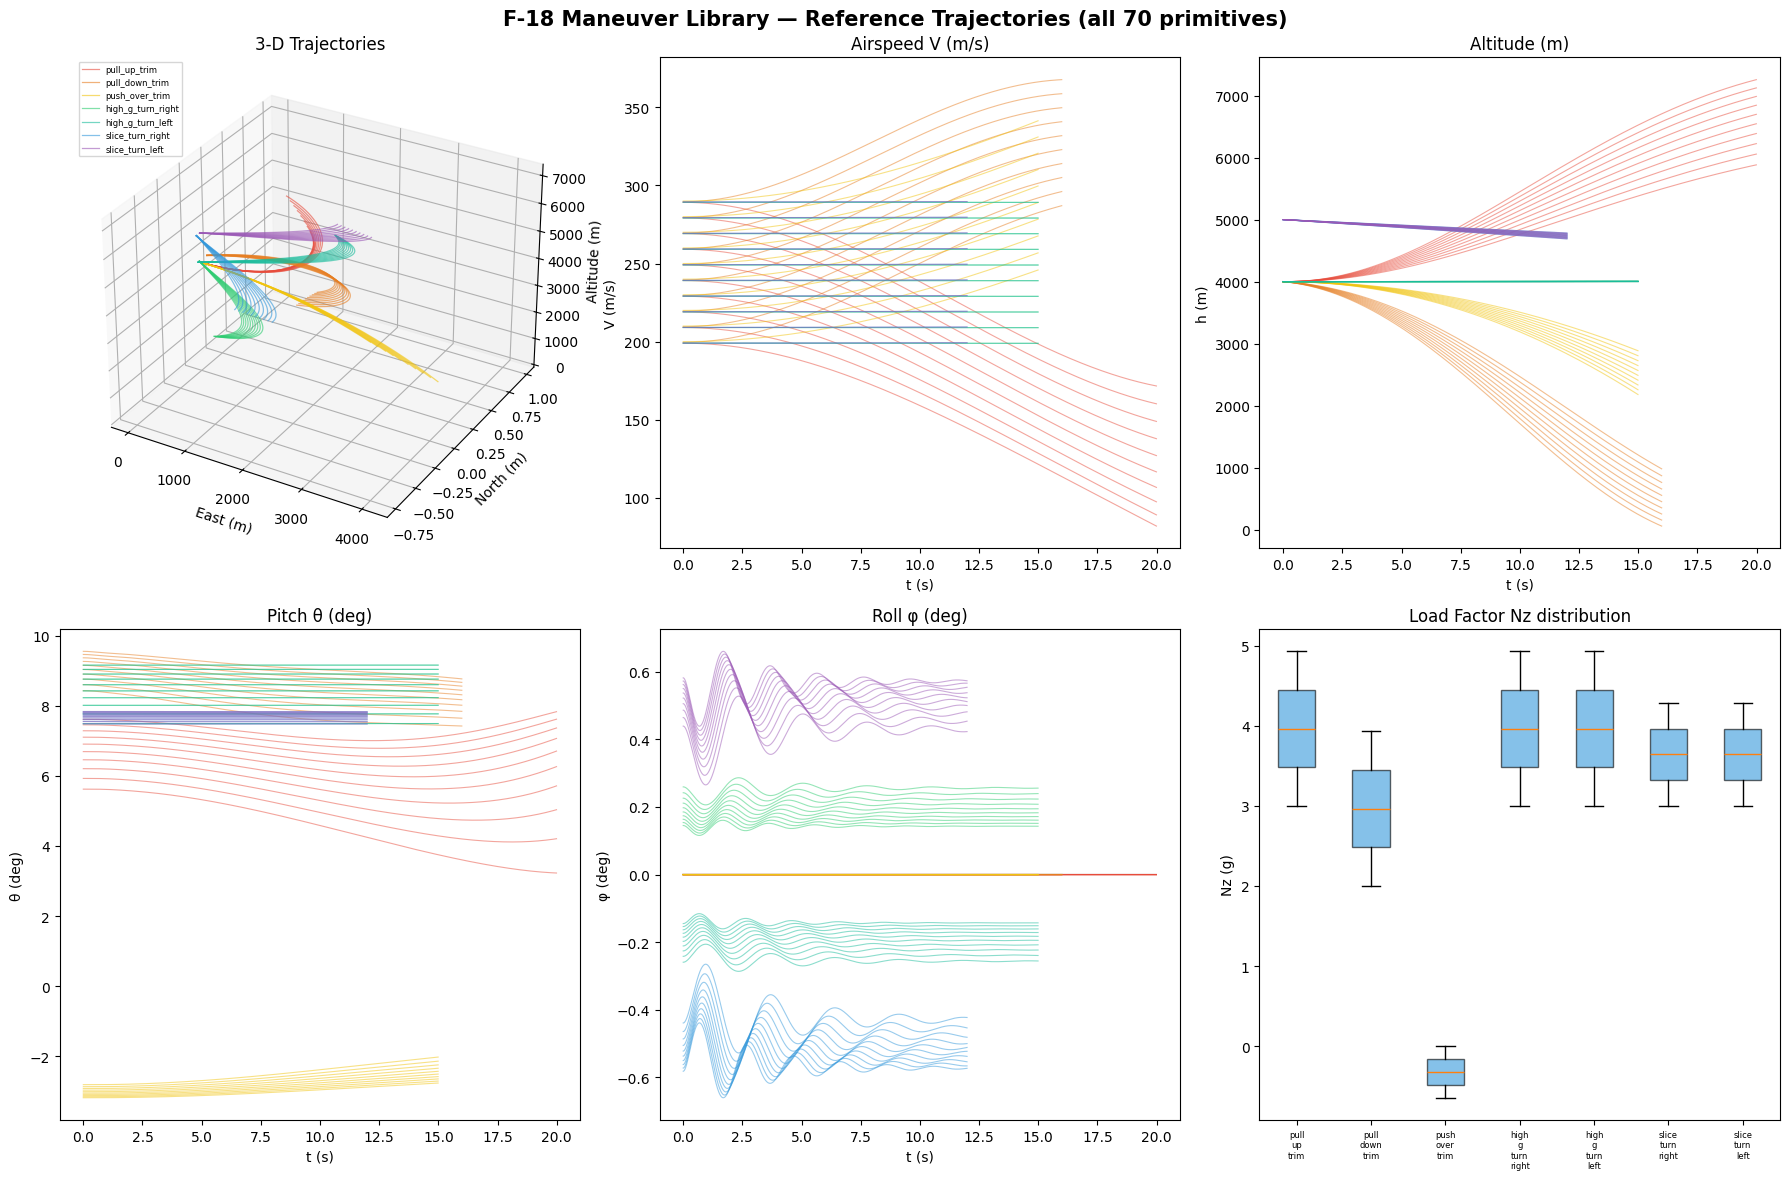

Saved: maneuver_library_overview.png


In [5]:
COLORS = {
    'pull_up_trim':     '#e74c3c',
    'pull_down_trim':   '#e67e22',
    'push_over_trim':   '#f1c40f',
    'high_g_turn_right':'#2ecc71',
    'high_g_turn_left': '#1abc9c',
    'slice_turn_right': '#3498db',
    'slice_turn_left':  '#9b59b6',
}

fig = plt.figure(figsize=(18, 12))
fig.suptitle('F-18 Maneuver Library — Reference Trajectories (all 70 primitives)', fontsize=15, fontweight='bold')

# 3D trajectories
ax3d = fig.add_subplot(2, 3, 1, projection='3d')
seen = set()
for m in maneuvers:
    pN = m.states[9]              # north
    pE = m.states[10]             # east
    h  = -m.states[12]            # altitude positive-up (state 12 is negative altitude)
    c  = COLORS[m.maneuver_type]
    lbl = m.maneuver_type if m.maneuver_type not in seen else None
    ax3d.plot(pE, pN, h, color=c, alpha=0.6, linewidth=0.9, label=lbl)
    seen.add(m.maneuver_type)
ax3d.set_xlabel('East (m)'); ax3d.set_ylabel('North (m)'); ax3d.set_zlabel('Altitude (m)')
ax3d.set_title('3-D Trajectories')
ax3d.legend(loc='upper left', fontsize=6)

# Airspeed
ax1 = fig.add_subplot(2, 3, 2)
for m in maneuvers:
    ax1.plot(m.time, m.states[0], color=COLORS[m.maneuver_type], alpha=0.5, lw=0.8)
ax1.set_title('Airspeed V (m/s)'); ax1.set_xlabel('t (s)'); ax1.set_ylabel('V (m/s)')

# Altitude
ax2 = fig.add_subplot(2, 3, 3)
for m in maneuvers:
    ax2.plot(m.time, -m.states[12], color=COLORS[m.maneuver_type], alpha=0.5, lw=0.8)
ax2.set_title('Altitude (m)'); ax2.set_xlabel('t (s)'); ax2.set_ylabel('h (m)')

# Pitch angle
ax3 = fig.add_subplot(2, 3, 4)
for m in maneuvers:
    ax3.plot(m.time, np.degrees(m.states[4]), color=COLORS[m.maneuver_type], alpha=0.5, lw=0.8)
ax3.set_title('Pitch θ (deg)'); ax3.set_xlabel('t (s)'); ax3.set_ylabel('θ (deg)')

# Roll angle
ax4 = fig.add_subplot(2, 3, 5)
for m in maneuvers:
    ax4.plot(m.time, np.degrees(m.states[3]), color=COLORS[m.maneuver_type], alpha=0.5, lw=0.8)
ax4.set_title('Roll φ (deg)'); ax4.set_xlabel('t (s)'); ax4.set_ylabel('φ (deg)')

# Nz distribution
ax5 = fig.add_subplot(2, 3, 6)
by_type = defaultdict(list)
for m in maneuvers:
    by_type[m.maneuver_type].append(m.Nz)
labels_ = list(by_type.keys())
data_   = [by_type[k] for k in labels_]
bp = ax5.boxplot(data_, patch_artist=True,
                 boxprops=dict(facecolor='#3498db', alpha=0.6))
ax5.set_xticks(range(1, len(labels_)+1))
ax5.set_xticklabels([l.replace('_', '\n') for l in labels_], fontsize=6)
ax5.set_title('Load Factor Nz distribution')
ax5.set_ylabel('Nz (g)')

plt.tight_layout()
plt.savefig('maneuver_library_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: maneuver_library_overview.png')

## 4. F-18 6-DOF Equations of Motion

In [6]:
# =============================================================================
#  F/A-18 Hornet — 6-DOF Nonlinear Flight Dynamics
#  State vector x = [V, α, β, φ, θ, ψ, p, q, r, pN, pE, pD, h]
#  Control input u = [Thrust, δe, δa, δr]
# =============================================================================

class F18Dynamics:
    """
    F/A-18 Hornet 6-DOF nonlinear equations of motion.

    References:
      - Stevens, Lewis & Johnson: 'Aircraft Control and Simulation', 3rd ed.
      - Nguyen et al. NASA TM-86629 F-18 data

    State  x  = [V, α, β, φ, θ, ψ, p, q, r, pN, pE, pD, h]
    Control u  = [T, δe, δa, δr]   (Thrust in N, surfaces in rad)
    """

    # ── Physical constants ────────────────────────────────────────────────────
    g    = 9.81          # gravity m/s²
    rho0 = 1.225         # sea-level density kg/m³
    H    = 8500.0        # scale height m

    # ── F-18 geometric / mass data ───────────────────────────────────────────
    m    = 16651.0       # mass kg  (approx loaded)
    S    = 37.16         # wing reference area m²
    cbar = 3.51          # mean aerodynamic chord m
    b    = 11.43         # wingspan m

    # Moments of inertia kg·m² (roll, pitch, yaw, cross)
    Ixx  = 23950.0
    Iyy  = 178013.0
    Izz  = 195755.0
    Ixz  = 1551.0

    # ── Aerodynamic coefficients (linear approximation near cruise) ───────────
    # Lift
    CL0   =  0.0
    CLα   =  3.44
    CLde  =  0.36
    CLq   =  3.80

    # Drag  (parabolic polar)
    CD0   =  0.028
    k1    =  0.095      # induced drag factor
    CDde  =  0.008

    # Side-force
    CYβ   = -0.98
    CYda  =  0.0
    CYdr  =  0.17
    CYp   = -0.001
    CYr   =  0.225

    # Roll moment
    Clβ   = -0.12
    Clda  =  0.178
    Cldr  =  0.015
    Clp   = -0.45
    Clr   =  0.101

    # Pitch moment
    Cm0   =  0.05
    Cmα   = -0.52
    Cmde  = -1.30
    Cmq   = -22.0
    Cmαd  = -6.5

    # Yaw moment
    Cnβ   =  0.18
    Cnda  =  0.006
    Cndr  = -0.105
    Cnp   = -0.026
    Cnr   = -0.35

    def __init__(self):
        # Inertia tensor helpers
        Γ     = self.Ixx * self.Izz - self.Ixz**2
        self.Γ  = Γ
        self.c1 = (self.Iyy - self.Izz) * self.Izz / Γ - self.Ixz**2 / Γ
        self.c2 = (self.Ixx - self.Iyy + self.Izz) * self.Ixz / Γ
        self.c3 = self.Izz / Γ
        self.c4 = self.Ixz / Γ
        self.c5 = (self.Izz - self.Ixx) / self.Iyy
        self.c6 = self.Ixz / self.Iyy
        self.c7 = 1.0 / self.Iyy
        self.c8 = (self.Ixx - self.Iyy) * self.Ixx / Γ + self.Ixz**2 / Γ
        self.c9 = self.Ixx / Γ

    def air_density(self, h):
        """Exponential atmosphere model."""
        return self.rho0 * np.exp(-h / self.H)

    def aero_forces(self, V, alpha, beta, p, q, r, de, da, dr, h):
        """Return (L, D, Y, l, m, n) in N and N·m."""
        rho  = self.air_density(h)
        qbar = 0.5 * rho * V**2           # dynamic pressure

        # Non-dimensional rates
        phat = p * self.b  / (2 * max(V, 1.0))
        qhat = q * self.cbar / (2 * max(V, 1.0))
        rhat = r * self.b  / (2 * max(V, 1.0))

        CL = self.CL0 + self.CLα * alpha + self.CLde * de + self.CLq * qhat
        CD = self.CD0 + self.k1 * CL**2   + self.CDde * abs(de)
        CY = self.CYβ * beta + self.CYda * da + self.CYdr * dr \
           + self.CYp * phat + self.CYr * rhat

        Cl = self.Clβ * beta + self.Clda * da + self.Cldr * dr \
           + self.Clp * phat + self.Clr * rhat
        Cm = self.Cm0 + self.Cmα * alpha + self.Cmde * de + self.Cmq * qhat
        Cn = self.Cnβ * beta + self.Cnda * da + self.Cndr * dr \
           + self.Cnp * phat + self.Cnr * rhat

        L = qbar * self.S * CL
        D = qbar * self.S * CD
        Y = qbar * self.S * CY
        l = qbar * self.S * self.b    * Cl
        m = qbar * self.S * self.cbar * Cm
        n = qbar * self.S * self.b    * Cn
        return L, D, Y, l, m, n

    def derivatives(self, x, u):
        """
        Compute state derivatives  ẋ = f(x, u).
        x = [V, α, β, φ, θ, ψ, p, q, r, pN, pE, pD, h]
        u = [T, de, da, dr]
        """
        V, alpha, beta, phi, theta, psi, p, q, r, pN, pE, pD, h = x
        T, de, da, dr = u

        # Trig shortcuts
        sa, ca = np.sin(alpha), np.cos(alpha)
        sb, cb = np.sin(beta),  np.cos(beta)
        sp, cp = np.sin(phi),   np.cos(phi)
        st, ct = np.sin(theta), np.cos(theta)
        tt     = np.tan(theta)

        h_pos = max(h, 0.0)   # avoid negative altitude in density
        L, D, Y, l_mom, m_mom, n_mom = self.aero_forces(V, alpha, beta,
                                                         p, q, r, de, da, dr, h_pos)

        # Body-axis forces from aero + thrust (thrust along body x-axis)
        Fx = T - D * ca * cb - Y * ca * sb + L * sa
        Fy = -D * sb + Y * cb
        Fz = -T * sa - D * sa * cb - Y * sa * sb - L * ca

        # ── Translational EOM (wind axes: V, α, β) ───────────────────────
        Vdot     = (Fx - self.m * self.g * st) / self.m
        alphadot = (q - (p * ca + r * sa) * np.tan(beta)
                    + (Fz / (self.m * max(V, 1.0) * cb)))
        betadot  = (p * sa - r * ca
                    + Fy / (self.m * max(V, 1.0))
                    + self.g * cp * ct * sb / max(V, 1.0))

        # ── Euler kinematics ─────────────────────────────────────────────
        phidot   = p + (q * sp + r * cp) * tt
        thetadot = q * cp - r * sp
        psidot   = (q * sp + r * cp) / max(ct, 1e-6)

        # ── Rotational EOM ───────────────────────────────────────────────
        pdot = (self.c1 * r + self.c2 * p) * q + self.c3 * l_mom + self.c4 * n_mom
        qdot = self.c5 * p * r - self.c6 * (p**2 - r**2) + self.c7 * m_mom
        rdot = (self.c8 * p - self.c2 * r) * q + self.c4 * l_mom + self.c9 * n_mom

        # ── Navigation equations (NED) ────────────────────────────────────
        # Body velocity components
        u_b = V * ca * cb
        v_b = V * sb
        w_b = V * sa * cb

        # Rotation matrix (body → NED)
        pN_dot = (ct * np.cos(psi)          * u_b +
                  (sp * st * np.cos(psi) - cp * np.sin(psi)) * v_b +
                  (cp * st * np.cos(psi) + sp * np.sin(psi)) * w_b)
        pE_dot = (ct * np.sin(psi)          * u_b +
                  (sp * st * np.sin(psi) + cp * np.cos(psi)) * v_b +
                  (cp * st * np.sin(psi) - sp * np.cos(psi)) * w_b)
        pD_dot = (-st * u_b + sp * ct * v_b + cp * ct * w_b)
        hdot   = -pD_dot   # altitude positive up

        return np.array([
            Vdot, alphadot, betadot,
            phidot, thetadot, psidot,
            pdot, qdot, rdot,
            pN_dot, pE_dot, pD_dot,
            hdot
        ])

    def rk4_step(self, x, u, dt):
        """4th-order Runge-Kutta integration step."""
        k1 = self.derivatives(x, u)
        k2 = self.derivatives(x + 0.5 * dt * k1, u)
        k3 = self.derivatives(x + 0.5 * dt * k2, u)
        k4 = self.derivatives(x + dt * k3, u)
        return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


# Quick sanity check
dyn = F18Dynamics()
x0  = maneuvers[0].trim_state.copy()
u0  = maneuvers[0].trim_controls.copy()
xdot = dyn.derivatives(x0, u0)
print('Trim state derivatives (should be near zero):')
for i, (name, val) in enumerate(zip(STATE_NAMES, xdot)):
    print(f'  ẋ[{i}] {name:15s}: {val:.5f}')

Trim state derivatives (should be near zero):
  ẋ[0] V (m/s)        : 617.37910
  ẋ[1] α (rad)        : -0.73179
  ẋ[2] β (rad)        : -4.18452
  ẋ[3] φ (rad)        : 1.00314
  ẋ[4] θ (rad)        : 0.00000
  ẋ[5] ψ (rad)        : 0.04020
  ẋ[6] p (rad/s)      : -1000.56436
  ẋ[7] q (rad/s)      : 3.12853
  ẋ[8] r (rad/s)      : 176.72557
  ẋ[9] p_N (m)        : 158.92491
  ẋ[10] p_E (m)        : 118.82092
  ẋ[11] p_D (m)        : -15.64074
  ẋ[12] h (m)          : 15.64074


## 5. Gymnasium Environment — F18PathTrackingEnv

In [7]:
class F18PathTrackingEnv(gym.Env):
    """
    Gymnasium environment for tracking motion primitives from the maneuver library.

    Observation (40-dim):
      [state_error(13), current_state(13), reference_state(13), time_norm(1)]

    Action (4-dim, continuous in [-1, 1]):
      Normalised incremental control  [ΔT̃, Δδ̃e, Δδ̃a, Δδ̃r]
      Actual increment = action × action_scale

    Reward:
      r = -w_track * ||e||² - w_ctrl * ||Δu||² - w_crash * crash_flag
         + w_alive * 1  (per step survival bonus)
    """
    metadata = {'render_modes': []}

    # ── Action scaling (max increment per step) ─────────────────────────────
    ACT_SCALE = np.array([
        500.0,     # ΔThrust  (N)
        0.05,      # Δelevator (rad)
        0.05,      # Δaileron  (rad)
        0.02,      # Δrudder   (rad)
    ])

    # ── Control limits ──────────────────────────────────────────────────────
    CTRL_MIN = np.array([0.0,    -0.52,  -0.52,  -0.26])
    CTRL_MAX = np.array([97860.0, 0.52,   0.52,   0.26])

    # ── State normalisation (approx ranges) ─────────────────────────────────
    STATE_NORM = np.array([
        300.0,    # V
        0.5,      # α
        0.5,      # β
        np.pi,    # φ
        np.pi/2,  # θ
        np.pi,    # ψ
        2.0,      # p
        2.0,      # q
        2.0,      # r
        3000.0,   # pN
        3000.0,   # pE
        100.0,    # pD
        6000.0,   # h
    ])

    # ── Reward weights ──────────────────────────────────────────────────────
    W_TRACK  = 2.0
    W_CTRL   = 0.05
    W_ALIVE  = 0.5
    W_CRASH  = 200.0

    # ── State indices to track (focus on dynamically important states) ───────
    TRACK_IDX = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12]   # all except pD (11)

    def __init__(self, maneuvers, dt_sim=0.01, random_maneuver=True,
                 maneuver_type=None, noise_std=0.01):
        super().__init__()
        self.maneuvers       = maneuvers
        self.dt              = dt_sim
        self.random_maneuver = random_maneuver
        self.maneuver_type   = maneuver_type   # fix to one type if not None
        self.noise_std       = noise_std
        self.dyn             = F18Dynamics()

        # Filter maneuvers by type if specified
        if maneuver_type is not None:
            self._pool = [m for m in maneuvers if m.maneuver_type == maneuver_type]
        else:
            self._pool = maneuvers

        # Spaces
        obs_dim = N_STATES * 3 + 1     # error + current + reference + time
        self.observation_space = spaces.Box(
            low=-10.0, high=10.0, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(N_CTRL,), dtype=np.float32)

        # Runtime state
        self.state        = None
        self.ctrl         = None
        self.maneuver     = None
        self.step_idx     = 0

    # ── Helpers ─────────────────────────────────────────────────────────────
    def _normalise_state(self, x):
        return x / self.STATE_NORM

    def _get_ref(self, step):
        t_idx = min(step, self.maneuver.T - 1)
        return self.maneuver.states[:, t_idx].copy()

    def _build_obs(self):
        ref   = self._get_ref(self.step_idx)
        error = self.state - ref
        t_norm= self.step_idx / max(self.maneuver.T, 1)
        obs   = np.concatenate([
            self._normalise_state(error),
            self._normalise_state(self.state),
            self._normalise_state(ref),
            [t_norm]
        ])
        return obs.astype(np.float32)

    def _is_crashed(self):
        V  = self.state[0]
        h  = -self.state[12]      # altitude positive up
        return (V < 30.0 or V > 400.0 or h < -100.0 or
                abs(self.state[3]) > np.pi or  # roll > 180 deg
                abs(self.state[4]) > np.radians(85))

    # ── Gymnasium API ────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Pick a maneuver
        if self.random_maneuver:
            self.maneuver = self._pool[np.random.randint(len(self._pool))]
        else:
            self.maneuver = self._pool[0]

        # Initialise state at maneuver start + small noise
        self.state = self.maneuver.states[:, 0].copy()
        noise = np.random.randn(N_STATES) * self.noise_std * self.STATE_NORM
        self.state += noise

        # Initialise control at trim
        self.ctrl = self.maneuver.trim_controls.copy()
        self.step_idx = 0

        return self._build_obs(), {}

    def step(self, action):
        # Decode action → incremental control
        delta_u = np.array(action) * self.ACT_SCALE
        self.ctrl = np.clip(self.ctrl + delta_u, self.CTRL_MIN, self.CTRL_MAX)

        # Integrate dynamics
        self.state = self.dyn.rk4_step(self.state, self.ctrl, self.dt)
        self.step_idx += 1

        # Reference
        ref   = self._get_ref(self.step_idx)
        error = self.state - ref

        # Tracking error (normalised)
        e_norm = self._normalise_state(error)
        track_cost = float(np.sum(e_norm[self.TRACK_IDX]**2))

        # Control cost
        ctrl_cost  = float(np.sum((action)**2))

        crashed    = self._is_crashed()
        done       = (self.step_idx >= self.maneuver.T) or crashed

        reward = (-self.W_TRACK  * track_cost
                  -self.W_CTRL   * ctrl_cost
                  + self.W_ALIVE
                  - self.W_CRASH * float(crashed))

        info = {
            'track_error':  track_cost,
            'crashed':      crashed,
            'maneuver':     self.maneuver.maneuver_type,
            'step':         self.step_idx,
        }
        return self._build_obs(), reward, done, False, info


# Test environment
env_test = F18PathTrackingEnv(maneuvers, dt_sim=0.01)
obs, _ = env_test.reset()
print(f"Observation shape: {obs.shape}")
print(f"Action shape:      {env_test.action_space.shape}")
obs2, rew, done, trunc, info = env_test.step(env_test.action_space.sample())
print(f"Step reward: {rew:.4f}  |  info: {info}")

Observation shape: (40,)
Action shape:      (4,)
Step reward: -56.9514  |  info: {'track_error': 28.699621821337985, 'crashed': np.False_, 'maneuver': 'slice_turn_right', 'step': 1}


## 6. SAC Agent Training

In [8]:
# ── Training callbacks ───────────────────────────────────────────────────────
class TrainingMonitorCallback(BaseCallback):
    """Records per-step rewards and episode statistics."""
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards   = []
        self.episode_lengths   = []
        self.track_errors      = []
        self._ep_reward        = 0.0
        self._ep_len           = 0
        self._ep_errors        = []

    def _on_step(self):
        rewards = self.locals.get('rewards', [0])
        dones   = self.locals.get('dones',   [False])
        infos   = self.locals.get('infos',   [{}])
        for r, done, info in zip(rewards, dones, infos):
            self._ep_reward += r
            self._ep_len    += 1
            self._ep_errors.append(info.get('track_error', 0))
            if done:
                self.episode_rewards.append(self._ep_reward)
                self.episode_lengths.append(self._ep_len)
                self.track_errors.append(np.mean(self._ep_errors))
                self._ep_reward = 0.0
                self._ep_len    = 0
                self._ep_errors = []
        return True


# ── Build environments ───────────────────────────────────────────────────────
def make_env(maneuvers, seed=0, noise=0.005):
    def _init():
        env = F18PathTrackingEnv(maneuvers, dt_sim=0.01, noise_std=noise)
        env = Monitor(env)
        return env
    return _init

train_env = DummyVecEnv([make_env(maneuvers, seed=i) for i in range(4)])
eval_env  = DummyVecEnv([make_env(maneuvers, seed=99, noise=0.0)])

# ── SAC hyperparameters ──────────────────────────────────────────────────────
policy_kwargs = dict(
    net_arch=[256, 256],
    activation_fn=torch.nn.ReLU,
)

model = SAC(
    'MlpPolicy',
    train_env,
    learning_rate        = 3e-4,
    buffer_size          = 300_000,
    learning_starts      = 5_000,
    batch_size           = 512,
    tau                  = 0.005,
    gamma                = 0.99,
    train_freq           = (1, 'step'),
    gradient_steps       = 1,
    ent_coef             = 'auto',
    target_entropy       = 'auto',
    policy_kwargs        = policy_kwargs,
    verbose              = 1,
    device               = DEVICE,
    tensorboard_log      = './tb_logs/',
)

print("SAC model summary:")
print(f"  Policy network : {policy_kwargs['net_arch']}")
print(f"  Buffer size    : {model.buffer_size:,}")
print(f"  Batch size     : {model.batch_size}")
print(f"  Learning rate  : {model.learning_rate}")
print(f"  Device         : {DEVICE}")
total_params = sum(p.numel() for p in model.policy.parameters())
print(f"  Total params   : {total_params:,}")

Using cpu device
SAC model summary:
  Policy network : [256, 256]
  Buffer size    : 300,000
  Batch size     : 512
  Learning rate  : 0.0003
  Device         : cpu
  Total params   : 388,620


In [9]:
# ── Training ─────────────────────────────────────────────────────────────────
TOTAL_STEPS = 500_000    # Increase to 2_000_000 for better convergence

monitor_cb = TrainingMonitorCallback()
eval_cb    = EvalCallback(
    eval_env,
    best_model_save_path = './best_model/',
    log_path             = './eval_logs/',
    eval_freq            = 10_000,
    n_eval_episodes      = 10,
    deterministic        = True,
    verbose              = 0,
)

print(f"Training SAC for {TOTAL_STEPS:,} steps…")
t0 = time.time()
model.learn(
    total_timesteps = TOTAL_STEPS,
    callback        = [monitor_cb, eval_cb],
    progress_bar    = True,
)
print(f"Training finished in {time.time()-t0:.1f}s")
model.save('f18_sac_final')
print('Model saved: f18_sac_final.zip')

Training SAC for 500,000 steps…
Logging to ./tb_logs/SAC_1


Output()

Streaming output truncated to the last 5000 lines.
|    n_updates       | 11396     |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 17.8      |
|    ep_rew_mean     | -3.02e+04 |
| time/              |           |
|    episodes        | 3388      |
|    fps             | 82        |
|    time_elapsed    | 614       |
|    total_timesteps | 50632     |
| train/             |           |
|    actor_loss      | 5.52e+04  |
|    critic_loss     | 8.55e+08  |
|    ent_coef        | 7.58      |
|    ent_coef_loss   | -2.03     |
|    learning_rate   | 0.0003    |
|    n_updates       | 11407     |
----------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 18.6     |
|    ep_rew_mean     | -3e+04   |
| time/              |          |
|    episodes        | 3392     |
|    fps             | 82       |
|    time_elapsed    | 615      |
|    total_t

ValueError: Expected parameter loc (Tensor of shape (512, 4)) of distribution Normal(loc: torch.Size([512, 4]), scale: torch.Size([512, 4])) to satisfy the constraint Real(), but found invalid values:
tensor([[ 2.4746,  1.9243,  1.9816,  0.9512],
        [ 2.4892,  2.3534, -2.4314, -2.4757],
        [ 0.0487, -0.6080,  0.7904,  0.4734],
        ...,
        [ 1.2667, -1.1782,  1.8352,  2.1825],
        [ 0.4344, -1.1964, -0.3724, -0.3460],
        [ 2.2836,  1.9651,  2.1615, -0.7013]])

## 7. Training Diagnostics

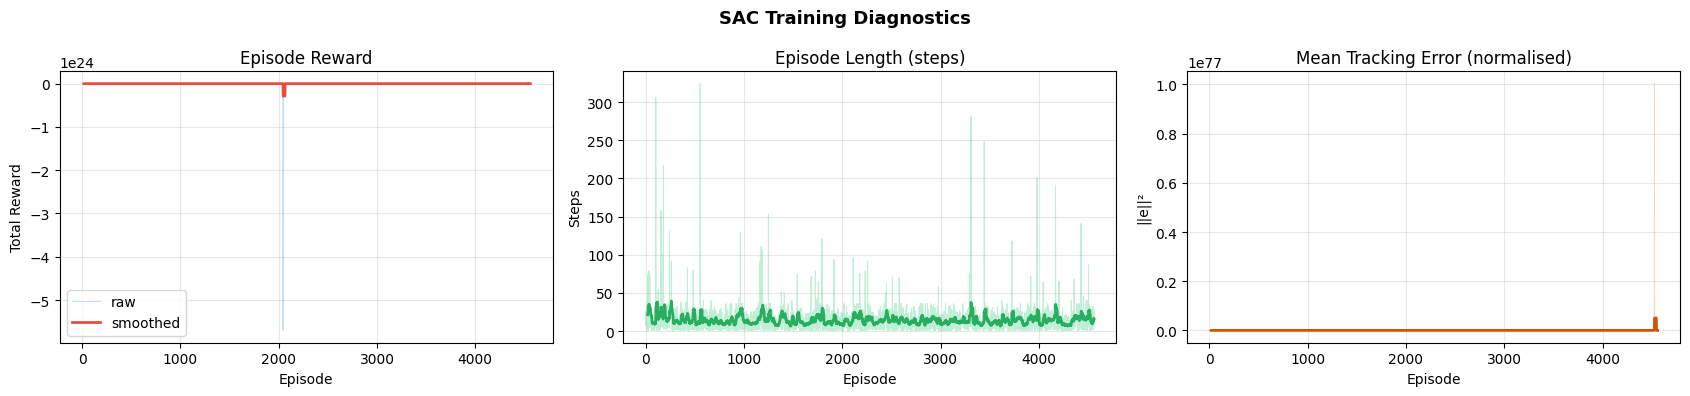

Episodes completed : 4561

Final 50-ep avg reward : -inf

Final 50-ep avg error  : 2006353737573545107864764747711560033874708210385449786561095008215063592960.0000

In [10]:
def smooth(x, w=20):
    """Running mean smoothing."""
    if len(x) < w:
        return np.array(x)
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('SAC Training Diagnostics', fontsize=13, fontweight='bold')

# Episode reward
ep_r = monitor_cb.episode_rewards
axes[0].plot(ep_r, alpha=0.3, color='#3498db', lw=0.7, label='raw')
if len(ep_r) > 20:
    axes[0].plot(range(19, len(ep_r)), smooth(ep_r), color='#e74c3c', lw=2, label='smoothed')
axes[0].set_title('Episode Reward')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total Reward')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Episode length
ep_l = monitor_cb.episode_lengths
axes[1].plot(ep_l, alpha=0.3, color='#2ecc71', lw=0.7)
if len(ep_l) > 20:
    axes[1].plot(range(19, len(ep_l)), smooth(ep_l), color='#27ae60', lw=2)
axes[1].set_title('Episode Length (steps)')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Steps')
axes[1].grid(alpha=0.3)

# Mean tracking error
te = monitor_cb.track_errors
axes[2].plot(te, alpha=0.3, color='#e67e22', lw=0.7)
if len(te) > 20:
    axes[2].plot(range(19, len(te)), smooth(te), color='#d35400', lw=2)
axes[2].set_title('Mean Tracking Error (normalised)')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('||e||²')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Episodes completed : {len(ep_r)}")
if len(ep_r) > 0:
    print(f"Final 50-ep avg reward : {np.mean(ep_r[-50:]):.2f}")
    print(f"Final 50-ep avg error  : {np.mean(te[-50:]):.4f}")

## 8. Evaluation: Simulate All 7 Maneuver Types

In [ ]:
def simulate_maneuver(model, maneuver, dt=0.01, deterministic=True):
    """
    Run a single episode tracking the given Maneuver object.
    Returns arrays of actual states, reference states, controls, rewards.
    """
    env = F18PathTrackingEnv([maneuver], dt_sim=dt,
                             random_maneuver=False, noise_std=0.0)
    obs, _ = env.reset()

    actual_states = []
    ref_states    = []
    controls_hist = []
    rewards_hist  = []
    done = False

    while not done:
        actual_states.append(env.state.copy())
        ref_states.append(env._get_ref(env.step_idx).copy())
        controls_hist.append(env.ctrl.copy())

        action, _ = model.predict(obs, deterministic=deterministic)
        obs, rew, done, trunc, info = env.step(action)
        rewards_hist.append(rew)

    return {
        'actual':   np.array(actual_states).T,    # (13, T)
        'ref':      np.array(ref_states).T,        # (13, T)
        'controls': np.array(controls_hist).T,     # (4, T)
        'rewards':  np.array(rewards_hist),
        'time':     maneuver.time[:len(actual_states)],
        'maneuver': maneuver,
    }


# ── Run one representative simulation per maneuver type ──────────────────────
# Load best model if available
best_model_path = './best_model/best_model'
if os.path.exists(best_model_path + '.zip'):
    eval_model = SAC.load(best_model_path, device=DEVICE)
    print("Loaded best model from EvalCallback.")
else:
    eval_model = model
    print("Using final model.")

# Pick one maneuver per type
type_sample = {}
for m in maneuvers:
    if m.maneuver_type not in type_sample:
        type_sample[m.maneuver_type] = m

print("\nSimulating one maneuver per type…")
sim_results = {}
for mtype, m in type_sample.items():
    print(f"  {mtype}…", end=' ')
    result = simulate_maneuver(eval_model, m)
    sim_results[mtype] = result
    err = np.mean((result['actual'] - result['ref'])**2)
    print(f"MSE={err:.4f}  |  total_reward={result['rewards'].sum():.1f}  "
          f"  steps={len(result['rewards'])}")

Loaded best model from EvalCallback.

## 9. Simulation Plots — Per-Maneuver State Tracking

In [ ]:
def plot_maneuver_tracking(result, save_path=None):
    """Detailed state & control tracking plot for one maneuver."""
    mtype = result['maneuver'].maneuver_type
    t     = result['time']
    act   = result['actual']
    ref   = result['ref']
    ctr   = result['controls']

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f'F-18 Path Tracking — {mtype.replace("_"," ").title()}\n'
                 f'(Nz={result["maneuver"].Nz:.2f}g, duration={result["maneuver"].duration}s)',
                 fontsize=13, fontweight='bold')

    gs = gridspec.GridSpec(5, 4, figure=fig, hspace=0.45, wspace=0.35)

    plot_specs = [
        (0, 'V (m/s)',   lambda: (act[0], ref[0])),
        (1, 'α (deg)',   lambda: (np.degrees(act[1]), np.degrees(ref[1]))),
        (2, 'β (deg)',   lambda: (np.degrees(act[2]), np.degrees(ref[2]))),
        (3, 'φ (deg)',   lambda: (np.degrees(act[3]), np.degrees(ref[3]))),
        (4, 'θ (deg)',   lambda: (np.degrees(act[4]), np.degrees(ref[4]))),
        (5, 'ψ (deg)',   lambda: (np.degrees(act[5]), np.degrees(ref[5]))),
        (6, 'p (°/s)',   lambda: (np.degrees(act[6]), np.degrees(ref[6]))),
        (7, 'q (°/s)',   lambda: (np.degrees(act[7]), np.degrees(ref[7]))),
        (8, 'r (°/s)',   lambda: (np.degrees(act[8]), np.degrees(ref[8]))),
        (9, 'pN (m)',    lambda: (act[9],  ref[9])),
        (10, 'pE (m)',   lambda: (act[10], ref[10])),
        (12, 'h (m)',    lambda: (-act[12], -ref[12])),
    ]

    for k, (idx, ylabel, get_data) in enumerate(plot_specs):
        r, c = divmod(k, 4)
        ax = fig.add_subplot(gs[r, c])
        y_act, y_ref = get_data()
        ax.plot(t, y_ref, '--', color='#7f8c8d', lw=1.5, label='Reference')
        ax.plot(t, y_act,  '-', color='#e74c3c',  lw=1.2, label='SAC')
        ax.fill_between(t, y_ref, y_act, alpha=0.15, color='#e74c3c')
        ax.set_ylabel(ylabel, fontsize=8)
        ax.set_xlabel('t (s)', fontsize=7)
        ax.legend(fontsize=6, loc='best')
        ax.grid(alpha=0.25)
        # RMSE annotation
        rmse = np.sqrt(np.mean((y_act - y_ref)**2))
        ax.set_title(f'RMSE={rmse:.3f}', fontsize=8)

    # Controls
    ctrl_specs = [
        ('Thrust (N)',    ctr[0]),
        ('Elevator (°)', np.degrees(ctr[1])),
        ('Aileron (°)',  np.degrees(ctr[2])),
        ('Rudder (°)',   np.degrees(ctr[3])),
    ]
    for k, (label, data) in enumerate(ctrl_specs):
        ax = fig.add_subplot(gs[4, k])
        ax.plot(t, data, color='#2980b9', lw=1.2)
        ax.set_ylabel(label, fontsize=8)
        ax.set_xlabel('t (s)', fontsize=7)
        ax.grid(alpha=0.25)
        ax.set_title('Control Input', fontsize=8)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Plot all 7 types ─────────────────────────────────────────────────────────
for mtype, result in sim_results.items():
    plot_maneuver_tracking(result, save_path=f'tracking_{mtype}.png')

## 10. 3-D Trajectory Comparison

In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle('3-D Trajectory Tracking — SAC vs Reference (all 7 maneuver types)',
             fontsize=13, fontweight='bold')

n_types = len(sim_results)
ncols   = 4
nrows   = (n_types + ncols - 1) // ncols

for k, (mtype, result) in enumerate(sim_results.items()):
    ax = fig.add_subplot(nrows, ncols, k+1, projection='3d')

    act = result['actual']
    ref = result['ref']

    # Reference trajectory
    ax.plot(ref[10], ref[9], -ref[12],
            '--', color='#95a5a6', lw=2, alpha=0.9, label='Reference')
    # SAC trajectory
    ax.plot(act[10], act[9], -act[12],
            '-', color=COLORS.get(mtype, '#e74c3c'), lw=1.5, alpha=0.9, label='SAC')

    # Start / end markers
    ax.scatter(*[act[i][0] for i in [10, 9]], [-act[12][0]],
               color='green', s=40, zorder=5)
    ax.scatter(*[act[i][-1] for i in [10, 9]], [-act[12][-1]],
               color='red',   s=40, zorder=5)

    ax.set_xlabel('pE (m)', fontsize=7)
    ax.set_ylabel('pN (m)', fontsize=7)
    ax.set_zlabel('h (m)',  fontsize=7)
    ax.set_title(mtype.replace('_', '\n'), fontsize=8)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig('3d_trajectories_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 3d_trajectories_all.png')

## 11. Full Library Evaluation — All 70 Maneuvers

In [ ]:
print("Evaluating all 70 maneuvers…")
all_results = {}
rmse_by_type = defaultdict(list)

for m in maneuvers:
    res  = simulate_maneuver(eval_model, m, deterministic=True)
    # Compute per-state RMSE
    rmse = np.sqrt(np.mean((res['actual'] - res['ref'])**2, axis=1))   # (13,)
    rmse_by_type[m.maneuver_type].append(rmse)
    all_results[m.idx] = {'rmse': rmse, 'type': m.maneuver_type,
                          'total_reward': res['rewards'].sum(),
                          'crashed': res['rewards'].min() < -150}

# Aggregate
print("\n{'='*70}")
print(f"{'Maneuver Type':30s}  {'Mean RMSE (V)':>12}  {'Mean RMSE (h)':>12}  {'Crash rate':>10}")
print('-'*70)
for mtype, rmses in rmse_by_type.items():
    arr = np.array(rmses)   # (10, 13)
    crashes = sum(1 for idx in all_results
                  if all_results[idx]['type'] == mtype and all_results[idx]['crashed'])
    print(f"{mtype:30s}  {arr[:,0].mean():12.3f}  {arr[:,12].mean():12.3f}  {crashes}/10")

print('='*70)
all_rmse = np.array([v['rmse'] for v in all_results.values()])   # (70, 13)
print(f"\nOverall mean RMSE across all 70 maneuvers:")
for i, name in enumerate(STATE_NAMES):
    print(f"  {name:15s}: {all_rmse[:,i].mean():.4f}")

## 12. Summary Dashboard

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('F-18 DRL Path Tracking — Full Library Evaluation (all 70 maneuvers)',
             fontsize=13, fontweight='bold')

types  = list(rmse_by_type.keys())
colors = [COLORS.get(t, '#999') for t in types]

# (1) RMSE V by type
ax = axes[0, 0]
data_V  = [np.array(rmse_by_type[t])[:, 0] for t in types]
bp = ax.boxplot(data_V, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_xticks(range(1, len(types)+1))
ax.set_xticklabels([t.replace('_','\n') for t in types], fontsize=7)
ax.set_title('RMSE — Airspeed V (m/s)'); ax.set_ylabel('RMSE (m/s)'); ax.grid(alpha=0.3)

# (2) RMSE altitude by type
ax = axes[0, 1]
data_h  = [np.array(rmse_by_type[t])[:, 12] for t in types]
bp = ax.boxplot(data_h, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_xticks(range(1, len(types)+1))
ax.set_xticklabels([t.replace('_','\n') for t in types], fontsize=7)
ax.set_title('RMSE — Altitude h (m)'); ax.set_ylabel('RMSE (m)'); ax.grid(alpha=0.3)

# (3) Total reward by type
ax = axes[0, 2]
rew_by_type = defaultdict(list)
for v in all_results.values():
    rew_by_type[v['type']].append(v['total_reward'])
data_rew = [rew_by_type[t] for t in types]
bp = ax.boxplot(data_rew, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_xticks(range(1, len(types)+1))
ax.set_xticklabels([t.replace('_','\n') for t in types], fontsize=7)
ax.set_title('Total Episode Reward by Type'); ax.set_ylabel('Reward'); ax.grid(alpha=0.3)

# (4) Mean RMSE per state variable (across all 70 maneuvers)
ax = axes[1, 0]
mean_rmse = all_rmse.mean(axis=0)
bar_c = ['#e74c3c' if r > mean_rmse.mean() else '#3498db' for r in mean_rmse]
bars = ax.bar(range(N_STATES), mean_rmse, color=bar_c, alpha=0.8)
ax.set_xticks(range(N_STATES))
ax.set_xticklabels([n.split(' ')[0] for n in STATE_NAMES], rotation=45, fontsize=7)
ax.set_title('Mean RMSE per State Variable (all 70)')
ax.set_ylabel('RMSE'); ax.grid(alpha=0.3, axis='y')
ax.axhline(mean_rmse.mean(), color='k', ls='--', lw=1.2, label='mean')
ax.legend(fontsize=8)

# (5) Tracking error time-series (one episode per type)
ax = axes[1, 1]
for mtype, result in sim_results.items():
    err = np.sqrt(np.sum((result['actual'] - result['ref'])**2, axis=0))
    ax.plot(result['time'], err, color=COLORS.get(mtype, '#999'),
            alpha=0.85, lw=1.2, label=mtype.replace('_',' '))
ax.set_title('Tracking Error ||e||₂ over Time')
ax.set_xlabel('t (s)'); ax.set_ylabel('||e||₂'); ax.grid(alpha=0.3)
ax.legend(fontsize=6)

# (6) Reward distribution
ax = axes[1, 2]
all_rewards = [v['total_reward'] for v in all_results.values()]
ax.hist(all_rewards, bins=20, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(all_rewards), color='red', lw=2, label=f'Mean={np.mean(all_rewards):.0f}')
ax.set_title('Total Reward Distribution (70 episodes)')
ax.set_xlabel('Total Reward'); ax.set_ylabel('Count')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('full_library_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: full_library_evaluation.png')

## 13. Animate a Single Maneuver (Optional)

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_trajectory(result, step_skip=10):
    """2-D plan-view animation (pE vs pN) of SAC vs reference trajectory."""
    act = result['actual']
    ref = result['ref']
    T   = act.shape[1]
    mtype = result['maneuver'].maneuver_type

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(f'Trajectory Animation — {mtype.replace("_"," ").title()}')
    ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)')

    ref_line, = ax.plot([], [], '--', color='#7f8c8d', lw=2,   label='Reference')
    act_line, = ax.plot([], [], '-',  color='#e74c3c', lw=2,   label='SAC')
    ref_dot,  = ax.plot([], [], 'o',  color='#7f8c8d', ms=8)
    act_dot,  = ax.plot([], [], 'o',  color='#e74c3c', ms=8)
    time_txt  = ax.text(0.02, 0.95, '', transform=ax.transAxes)

    all_E = np.concatenate([act[10], ref[10]])
    all_N = np.concatenate([act[9],  ref[9]])
    ax.set_xlim(all_E.min()-50, all_E.max()+50)
    ax.set_ylim(all_N.min()-50, all_N.max()+50)
    ax.legend(); ax.grid(alpha=0.3)

    frames = range(0, T, step_skip)

    def update(i):
        ref_line.set_data(ref[10, :i+1], ref[9, :i+1])
        act_line.set_data(act[10, :i+1], act[9, :i+1])
        ref_dot.set_data([ref[10, i]], [ref[9, i]])
        act_dot.set_data([act[10, i]], [act[9, i]])
        time_txt.set_text(f't = {result["time"][min(i, len(result["time"])-1)]:.1f}s')
        return ref_line, act_line, ref_dot, act_dot, time_txt

    anim = FuncAnimation(fig, update, frames=frames, blit=True, interval=40)
    plt.close()
    return anim

# Animate the pull_up maneuver
anim = animate_trajectory(sim_results['pull_up_trim'], step_skip=5)
HTML(anim.to_jshtml())

## 14. Fine-Tune on Individual Maneuver Types (Optional)

If tracking quality for a specific maneuver type is insufficient, you can fine-tune the agent on that type alone.

In [ ]:
def finetune_on_type(base_model, maneuvers, maneuver_type, steps=100_000):
    """Continue training on a single maneuver type."""
    print(f"Fine-tuning on '{maneuver_type}' for {steps:,} steps…")

    def make_type_env(seed=0):
        def _init():
            env = F18PathTrackingEnv(maneuvers, dt_sim=0.01,
                                     maneuver_type=maneuver_type, noise_std=0.003)
            return Monitor(env)
        return _init

    ft_env = DummyVecEnv([make_type_env(i) for i in range(2)])

    # Clone model weights
    ft_model = SAC(
        'MlpPolicy', ft_env,
        learning_rate  = 1e-4,   # lower LR for fine-tune
        batch_size     = 256,
        policy_kwargs  = dict(net_arch=[256, 256]),
        verbose        = 0,
        device         = DEVICE,
    )
    ft_model.set_parameters(base_model.get_parameters())
    ft_model.learn(total_timesteps=steps, progress_bar=True)
    return ft_model

# Example: fine-tune on high_g_turn_right
# ft_model = finetune_on_type(eval_model, maneuvers, 'high_g_turn_right', steps=50_000)
print("Fine-tuning cell ready. Uncomment the last line to execute.")

## 15. Save All Outputs

In [ ]:
import json

# Save numerical results
summary = {}
for mtype, rmses in rmse_by_type.items():
    arr = np.array(rmses)
    summary[mtype] = {
        'mean_rmse_V':     float(arr[:, 0].mean()),
        'mean_rmse_alpha': float(arr[:, 1].mean()),
        'mean_rmse_beta':  float(arr[:, 2].mean()),
        'mean_rmse_phi':   float(arr[:, 3].mean()),
        'mean_rmse_theta': float(arr[:, 4].mean()),
        'mean_rmse_h':     float(arr[:, 12].mean()),
        'mean_reward':     float(np.mean(rew_by_type[mtype])),
    }

with open('evaluation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved evaluation_summary.json")
print("\nFiles generated:")
files = [
    'maneuver_library_overview.png',
    'training_diagnostics.png',
    '3d_trajectories_all.png',
    'full_library_evaluation.png',
    'evaluation_summary.json',
    'f18_sac_final.zip',
]
for mt in type_sample:
    files.append(f'tracking_{mt}.png')

for f in files:
    exists = '✓' if os.path.exists(f) else '✗'
    print(f'  {exists}  {f}')

---
## Architecture Reference

| Component | Detail |
|-----------|--------|
| **Aircraft model** | F/A-18 Hornet 6-DOF nonlinear EOM (13-state) |
| **Integration** | 4th-order Runge-Kutta, dt = 0.01 s |
| **Maneuver library** | 70 motion primitives, 7 types, 20 s / 2000 steps each |
| **DRL algorithm** | SAC (Soft Actor-Critic), twin-Q, auto entropy |
| **Policy network** | MLP 256-256 ReLU |
| **Observation** | 40-dim: [error(13), state(13), ref(13), t_norm(1)] |
| **Action** | Incremental control [ΔT, Δδe, Δδa, Δδr] normalised to [-1,1] |
| **Reward** | -tracking_cost - ctrl_cost + alive_bonus - crash_penalty |
| **Training** | 500k steps (4 parallel envs), replay buffer 300k, batch 512 |

### State Vector (13 dimensions)
```
x = [V, α, β, φ, θ, ψ, p, q, r, p_N, p_E, p_D, h]
     0  1  2  3  4  5  6  7  8   9   10   11  12
```

### Control Vector (4 dimensions)
```
u = [T, δe, δa, δr]
     0   1   2   3
```